In [1]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import warnings as w
w.filterwarnings("ignore")

In [3]:
import seaborn as sns

In [4]:
user = 'postgres'
password = 'root'
host = 'localhost'
port = '5432'
database = 'banking_case'

# Create engine
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}')

In [5]:
df = pd.read_sql("SELECT * FROM customer", engine)

In [6]:
df.head()

,client_id,name,age,location_id,joined_bank,banking_contact,nationality,occupation,fee_structure,loyalty_classification,...,bank_deposits,checking_accounts,saving_accounts,foreign_currency_account,business_lending,properties_owned,risk_weighting,brid,genderid,iaid
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   client_id                 2940 non-null   object 
 1   name                      2940 non-null   object 
 2   age                       2940 non-null   int64  
 3   location_id               2940 non-null   int64  
 4   joined_bank               2940 non-null   object 
 5   banking_contact           2940 non-null   object 
 6   nationality               2940 non-null   object 
 7   occupation                2940 non-null   object 
 8   fee_structure             2940 non-null   object 
 9   loyalty_classification    2940 non-null   object 
 10  estimated_income          2940 non-null   float64
 11  superannuation_savings    2940 non-null   float64
 12  amount_of_credit_cards    2940 non-null   int64  
 13  credit_card_balance       2940 non-null   float64
 14  bank_loa

In [8]:
df.isnull().sum()

client_id                   0
name                        0
age                         0
location_id                 0
joined_bank                 0
banking_contact             0
nationality                 0
occupation                  0
fee_structure               0
loyalty_classification      0
estimated_income            0
superannuation_savings      0
amount_of_credit_cards      0
credit_card_balance         0
bank_loans                  0
bank_deposits               0
checking_accounts           0
saving_accounts             0
foreign_currency_account    0
business_lending            0
properties_owned            0
risk_weighting              0
brid                        0
genderid                    0
iaid                        0
dtype: int64

In [9]:
df['occupation'].nunique()

195

In [10]:
df.nunique()

client_id                   2940
name                        2855
age                           69
location_id                 2834
joined_bank                 2532
banking_contact               49
nationality                    5
occupation                   195
fee_structure                  3
loyalty_classification         4
estimated_income            2940
superannuation_savings      2937
amount_of_credit_cards         3
credit_card_balance         2938
bank_loans                  2914
bank_deposits               2907
checking_accounts           2907
saving_accounts             2907
foreign_currency_account    2940
business_lending            2927
properties_owned               4
risk_weighting                 5
brid                           4
genderid                       2
iaid                          22
dtype: int64

In [11]:
# Original columns kept as-is for correlation heatmap
# New label columns created for plots and analysis

df['gender']             = df['genderid'].map({1: 'Male', 2: 'Female'})

df['banking_relation']   = df['brid'].map({1: 'Retail', 2: 'Institutional', 
                                            3: 'Private Bank', 4: 'Commercial'})

df['risk_label']         = df['risk_weighting'].map({1: 'Very Low', 2: 'Low', 
                                                      3: 'Medium',  4: 'High', 
                                                      5: 'Very High'})

df['properties_label']   = df['properties_owned'].map({0: 'No Property', 1: 'One', 
                                                        2: 'Two', 3: 'Three or more'})

In [12]:
categorical_col = ["nationality","fee_structure","loyalty_classification","amount_of_credit_cards",
                   "banking_relation","gender","risk_label","properties_label" ]

In [13]:
for col in categorical_col:
    print(df[col].value_counts())
    print()

nationality
European      1283
Asian          744
American       494
Australian     245
African        174
Name: count, dtype: int64

fee_structure
High    1441
Mid      944
Low      555
Name: count, dtype: int64

loyalty_classification
Jade        1304
Silver       754
Gold         574
Platinum     308
Name: count, dtype: int64

amount_of_credit_cards
1    1880
2     755
3     305
Name: count, dtype: int64

banking_relation
Private Bank     1318
Retail            650
Institutional     488
Commercial        484
Name: count, dtype: int64

gender
Female    1487
Male      1453
Name: count, dtype: int64

risk_label
Low          1200
Very Low      818
Medium        448
High          318
Very High     156
Name: count, dtype: int64

properties_label
One              762
Two              761
Three or more    727
No Property      690
Name: count, dtype: int64



In [14]:
df.describe()                   
 

,age,location_id,estimated_income,superannuation_savings,amount_of_credit_cards,credit_card_balance,bank_loans,bank_deposits,checking_accounts,saving_accounts,foreign_currency_account,business_lending,properties_owned,risk_weighting,brid,genderid,iaid
count,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2.940000e+03,2.940000e+03,2.940000e+03,2.940000e+03,2940.000000,2.940000e+03,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000
mean,51.052721,21556.638776,171474.564701,25537.537588,1.464286,3174.061119,5.929354e+05,6.696077e+05,3.196736e+05,2.325065e+05,29924.059065,8.663040e+05,1.518707,2.249660,2.556463,1.505782,10.420408
std,19.865992,12452.561124,112256.335403,16293.994988,0.675546,2499.212657,4.586359e+05,6.458076e+05,2.812101e+05,2.302543e+05,23169.058451,6.401003e+05,1.101821,1.130894,1.009251,0.500052,5.974096
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82742.115000,12506.737500,1.000000,1231.735000,2.396281e+05,2.042351e+05,1.193008e+05,7.444691e+04,11927.090000,3.753972e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21147.500000,142313.480000,22371.550000,1.000000,2560.165000,4.821348e+05,4.590371e+05,2.417221e+05,1.634431e+05,24316.860000,7.115343e+05,2.000000,2.000000,3.000000,2.000000,10.500000
75%,69.000000,31985.750000,242817.330000,35476.867500,2.000000,4522.632500,8.295056e+05,9.414633e+05,4.338220e+05,3.136847e+05,42027.797500,1.183531e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,521159.980000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [15]:
df.describe(include='object')

,client_id,name,joined_bank,banking_contact,nationality,occupation,fee_structure,loyalty_classification,gender,banking_relation,risk_label,properties_label
count,2940,2940,2940,2940,2940,2940,2940,2940,2940,2940,2940,2940
unique,2940,2855,2532,49,5,195,3,4,2,4,5,4
top,IND81288,Raymond Mills,2019-03-17,Ernest Rivera,European,Structural Analysis Engineer,High,Jade,Female,Private Bank,Low,One
freq,1,2,4,77,1283,26,1441,1304,1487,1318,1200,762


In [16]:
# converting date column to date format , current format is in string 

In [17]:
df['joined_bank'] = pd.to_datetime(df['joined_bank'] , format = '%d-%m-%Y')

In [18]:
df['joined_bank'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2940 entries, 0 to 2939
Series name: joined_bank
Non-Null Count  Dtype         
--------------  -----         
2940 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 23.1 KB


In [19]:
# extracting year from joined_date and creating column year 
df['tenure_year'] = df['joined_bank'].dt.year

In [20]:
df[df['age'] == 17]

,client_id,name,age,location_id,joined_bank,banking_contact,nationality,occupation,fee_structure,loyalty_classification,...,properties_owned,risk_weighting,brid,genderid,iaid,gender,banking_relation,risk_label,properties_label,tenure_year
94,IND35725,Tammy Willis,17,29867,2012-11-02,Jerry Green,European,Operator,High,Jade,...,3,3,3,2,8,Female,Private Bank,Medium,Three or more,2012
163,IND88778,Albert Bryant,17,785,2018-01-25,James Castillo,European,Structural Analysis Engineer,High,Jade,...,1,2,4,1,9,Male,Commercial,Low,One,2018
228,IND90057,Roy Snyder,17,2290,2014-08-04,Paul Larson,European,Office Assistant I,Mid,Silver,...,0,2,3,1,4,Male,Private Bank,Low,No Property,2014
251,IND42646,Chris Ross,17,14360,2020-07-03,Victor Ramos,European,Recruiter,High,Jade,...,2,1,3,1,15,Male,Private Bank,Very Low,Two,2020
375,IND32547,Wayne Hart,17,29676,2021-05-30,Adam Hernandez,Asian,Help Desk Technician,High,Jade,...,1,5,3,2,3,Female,Private Bank,Very High,One,2021
529,IND18979,Brian Stevens,17,1628,2019-02-10,Gregory Simmons,European,Electrical Engineer,Mid,Jade,...,3,2,3,2,22,Female,Private Bank,Low,Three or more,2019
615,IND49045,Howard Hunter,17,42531,2004-06-10,Adam Hernandez,Australian,Paralegal,Mid,Platinum,...,0,4,4,2,6,Female,Commercial,High,No Property,2004
792,IND69349,Benjamin Garza,17,18379,2004-12-08,Mark Montgomery,Asian,Media Manager IV,Mid,Gold,...,0,4,3,2,16,Female,Private Bank,High,No Property,2004
1089,IND28522,Raymond Mccoy,17,13553,2013-01-25,Samuel Fowler,Asian,Senior Financial Analyst,High,Jade,...,2,3,1,1,13,Male,Retail,Medium,Two,2013
1092,IND88639,Anthony Oliver,17,11409,2004-12-10,Adam Hernandez,African,Human Resources Assistant III,High,Jade,...,2,3,3,2,16,Female,Private Bank,Medium,Two,2004


In [21]:
num_cols = ['age', 'estimated_income', 'superannuation_savings', 'bank_loans',
            'bank_deposits', 'credit_card_balance', 'saving_accounts',
            'checking_accounts', 'foreign_currency_account', 'business_lending',
            'properties_owned', 'risk_weighting', 'amount_of_credit_cards']
# this are numerical columns

# univariate analysis for numerical col

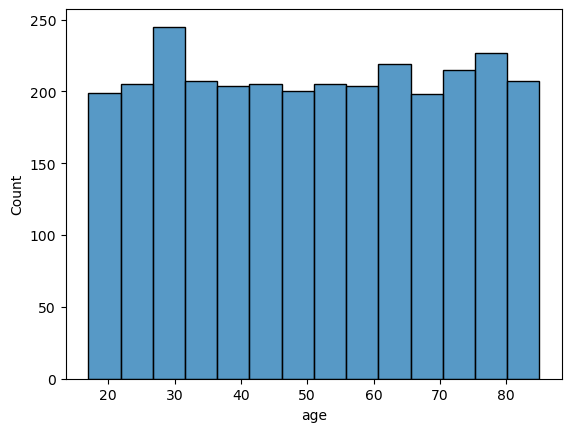

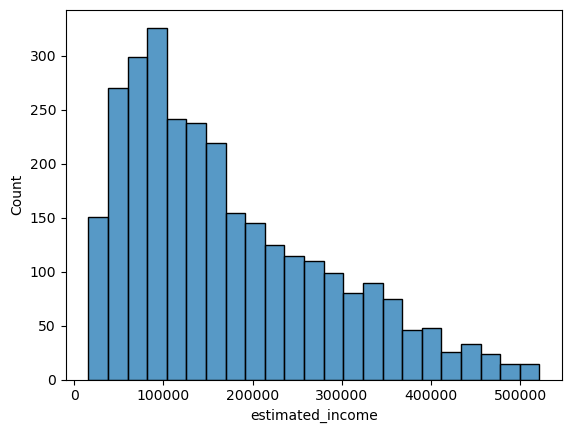

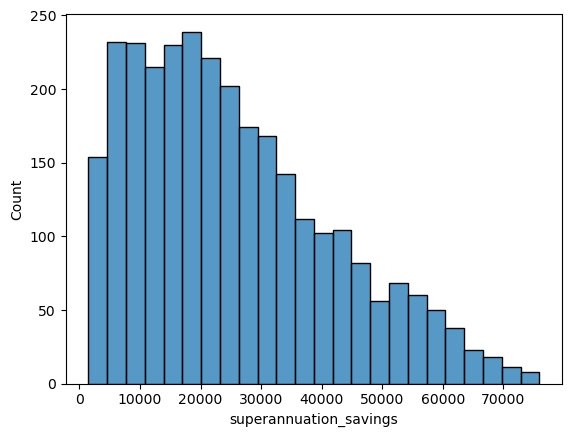

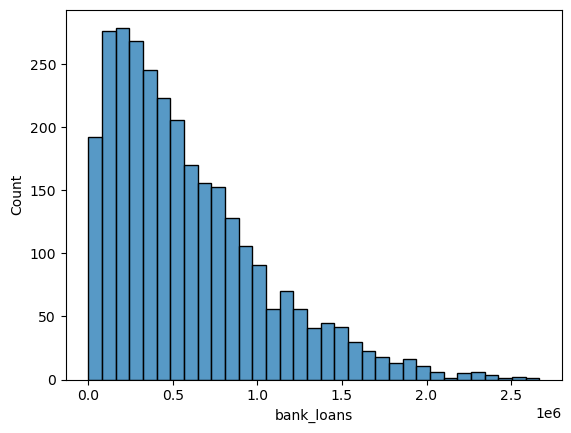

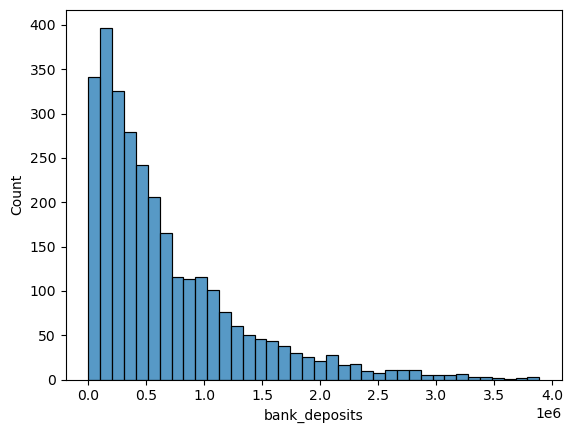

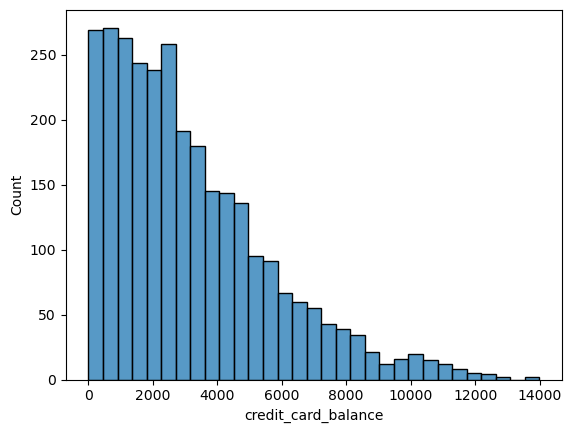

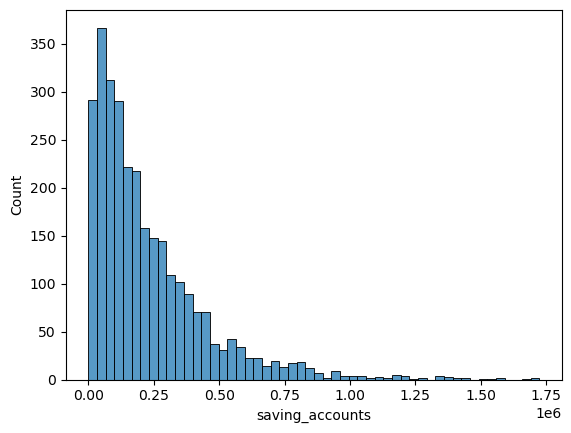

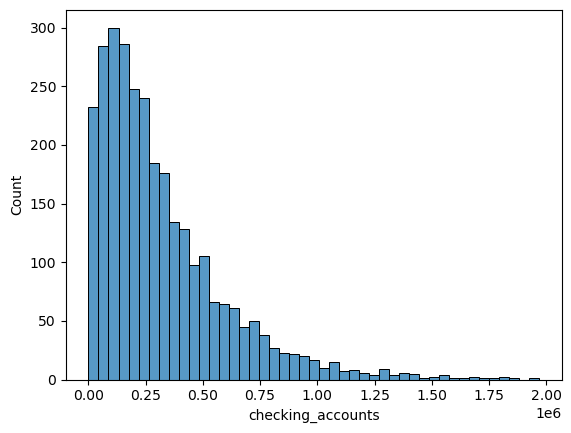

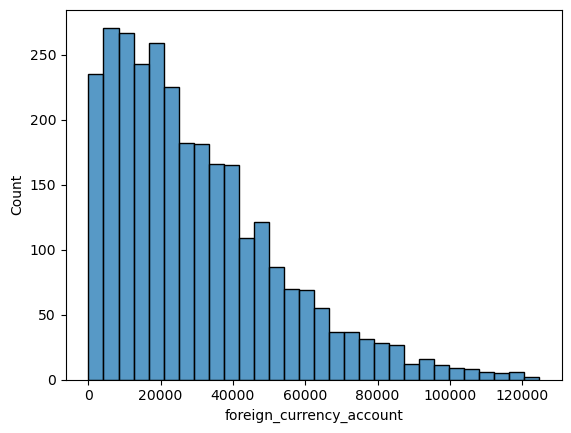

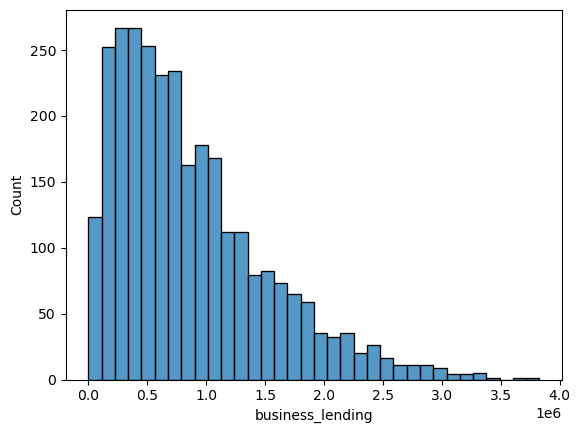

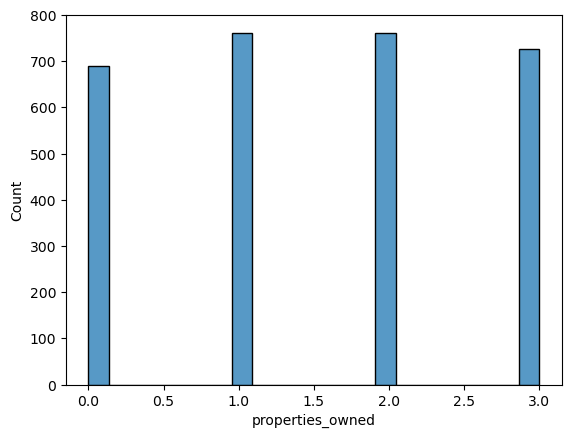

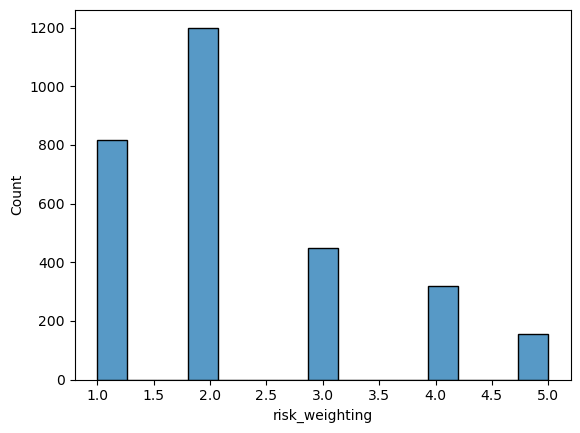

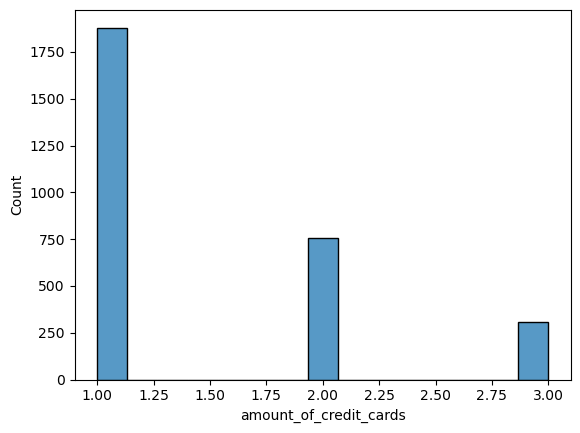

In [22]:
for i ,col in enumerate(num_cols):
    plt.figure(i)
    sns.histplot(df[col])


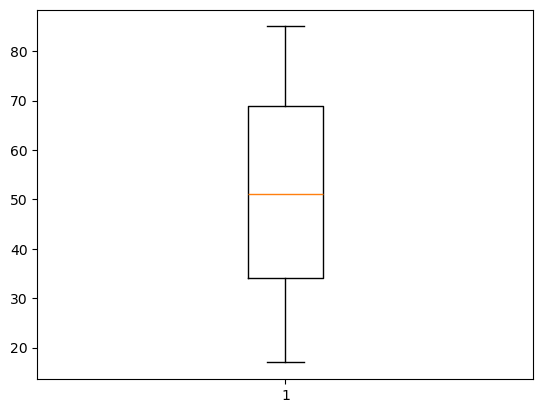

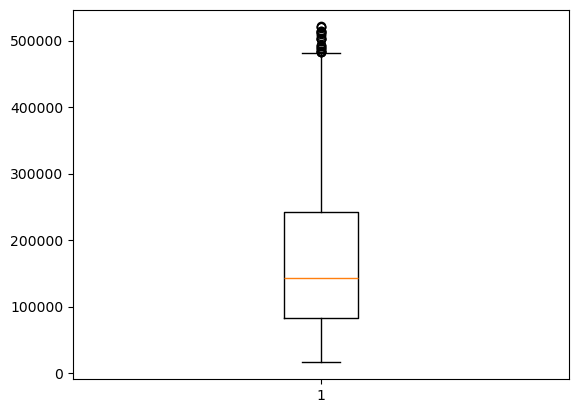

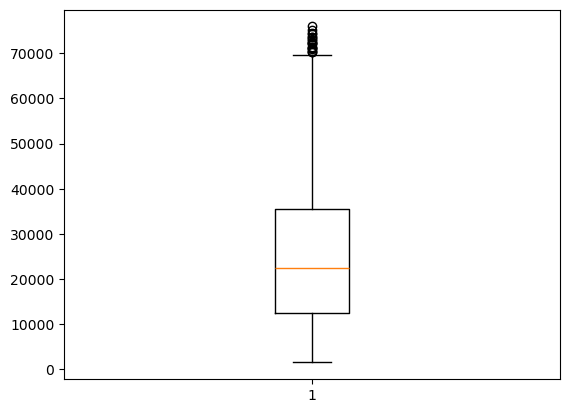

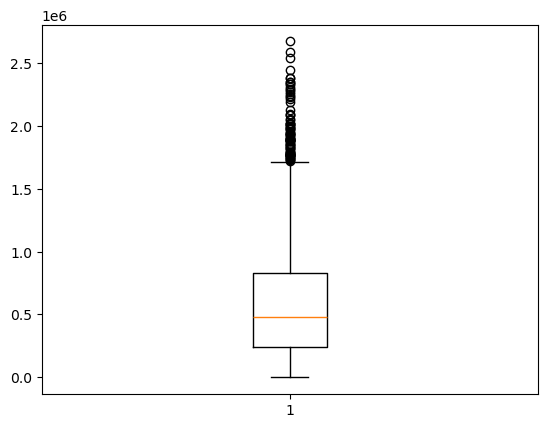

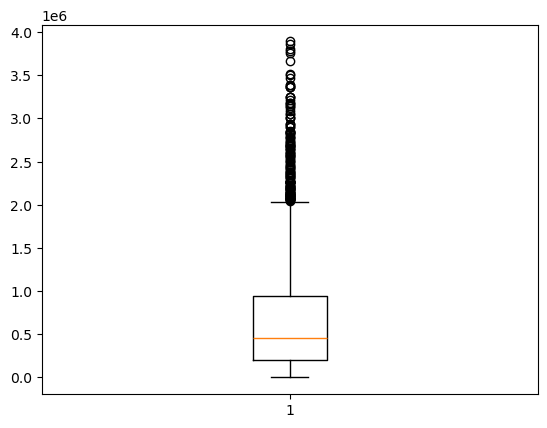

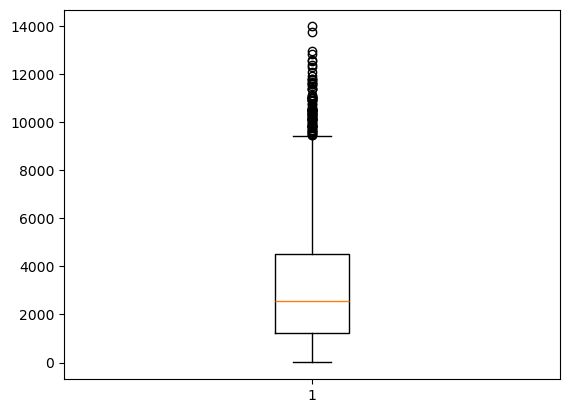

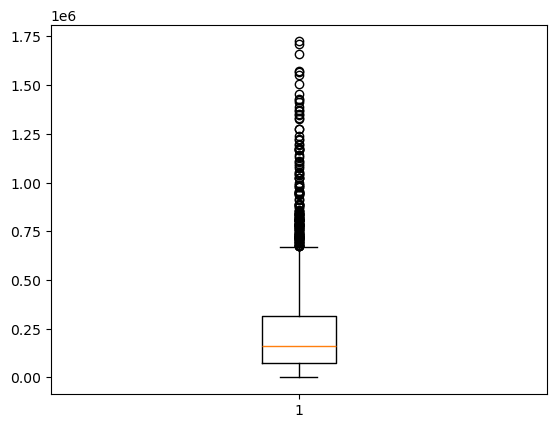

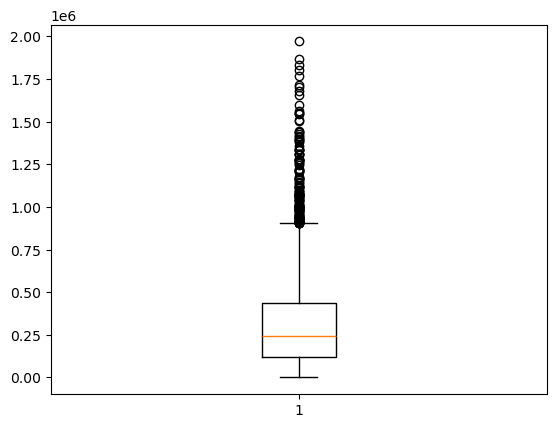

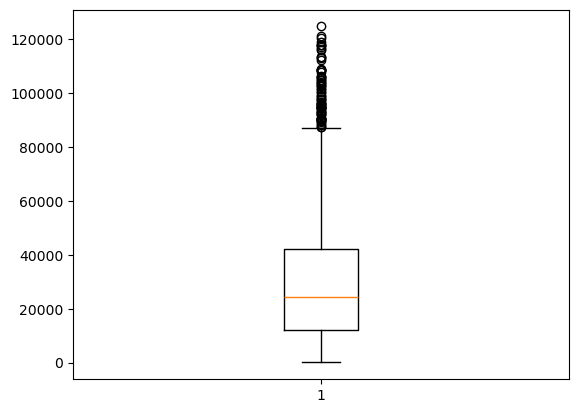

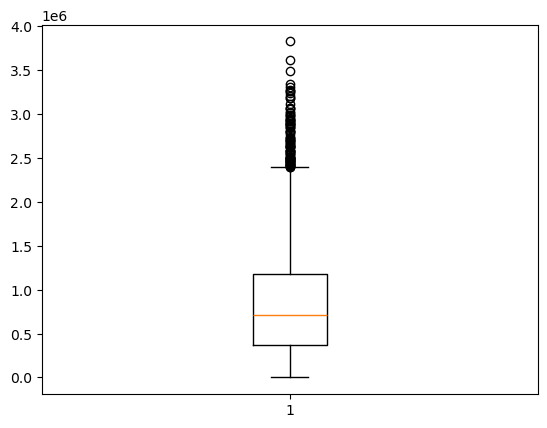

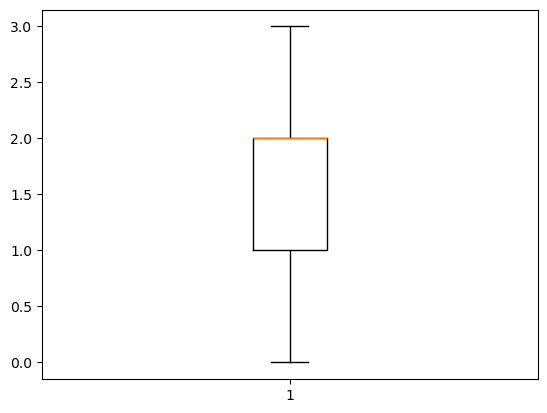

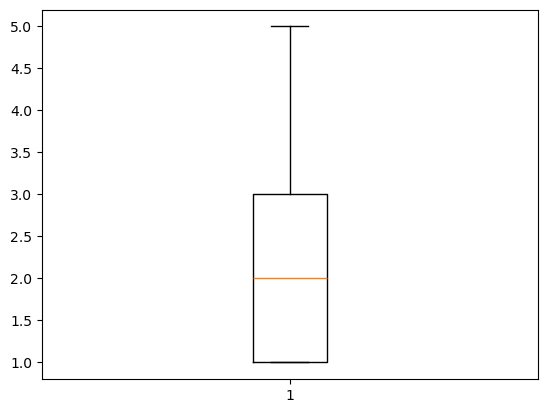

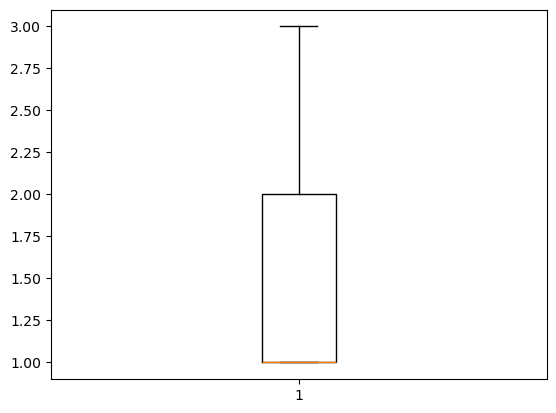

In [23]:
for i , col in enumerate(num_cols):
    plt.figure(i)
    plt.boxplot(df[col])

# Univariate analysis for Categorical column

In [24]:
categorical_col = ["nationality","fee_structure","loyalty_classification","amount_of_credit_cards",
                   "banking_relation","gender","risk_label","properties_label" ]

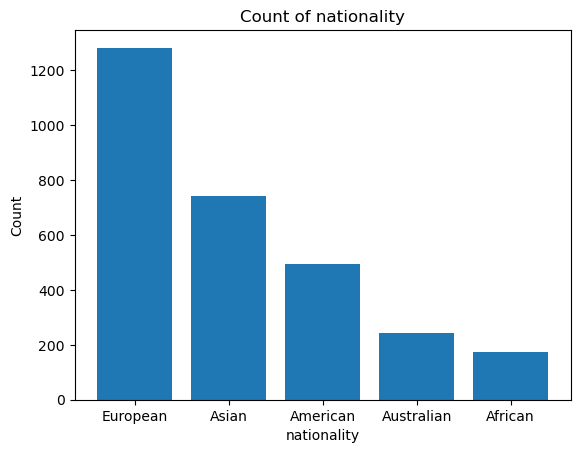

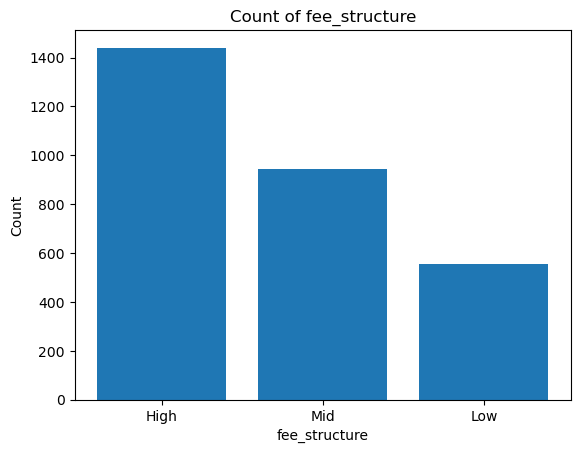

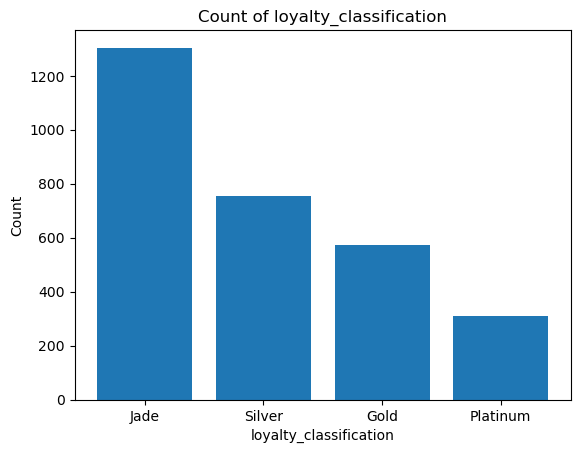

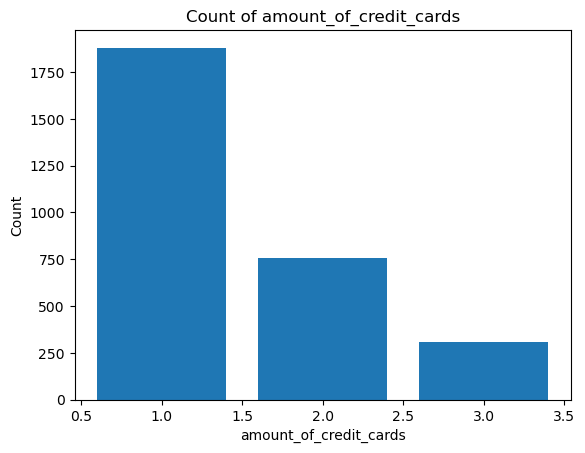

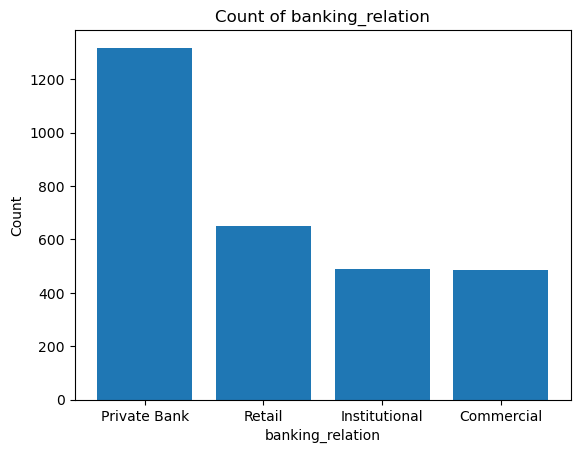

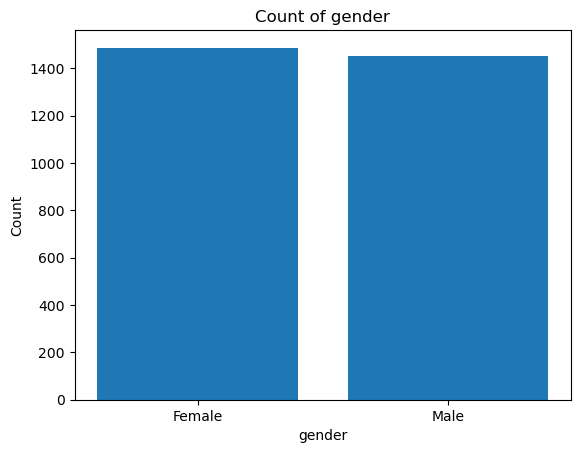

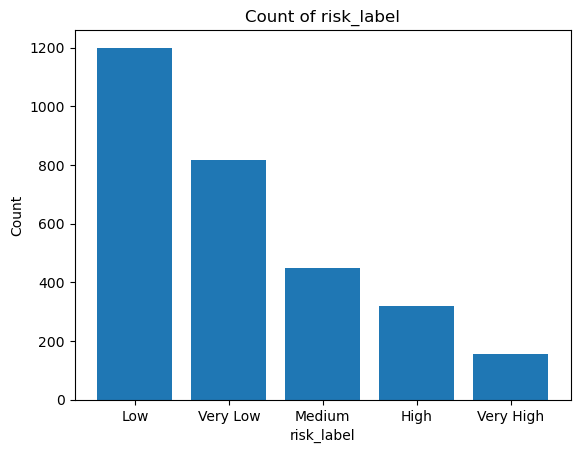

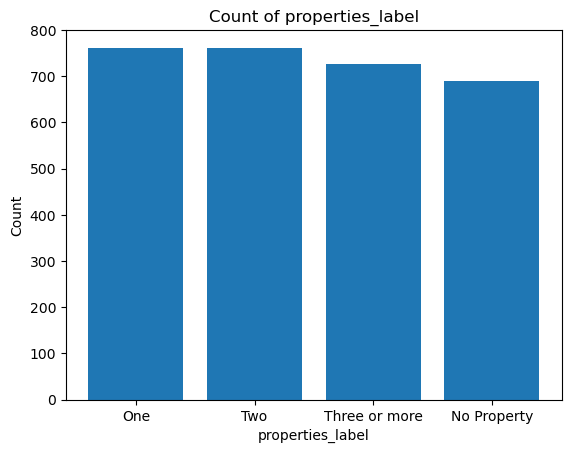

In [25]:
for i , col in enumerate(categorical_col):
    y = df[col].value_counts()
    plt.figure(i)
    plt.bar(x = y.index ,height = y.values)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Count of {col}")

# Bivariate Analysis

# Categorical vs Numerical

In [26]:
num_cols = ['age', 'estimated_income', 'superannuation_savings', 'bank_loans',
            'bank_deposits', 'credit_card_balance', 'saving_accounts',
            'checking_accounts', 'foreign_currency_account', 'business_lending',
            'properties_owned', 'risk_weighting', 'amount_of_credit_cards']


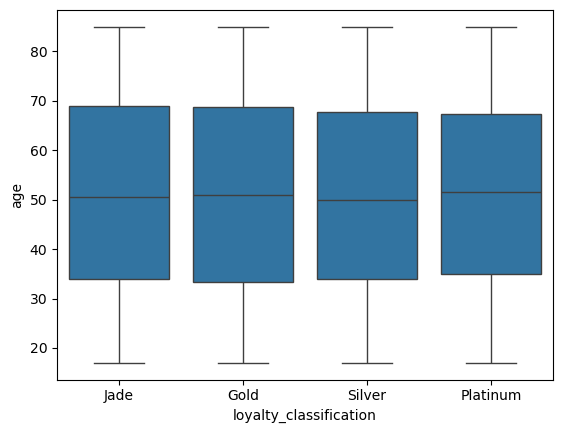

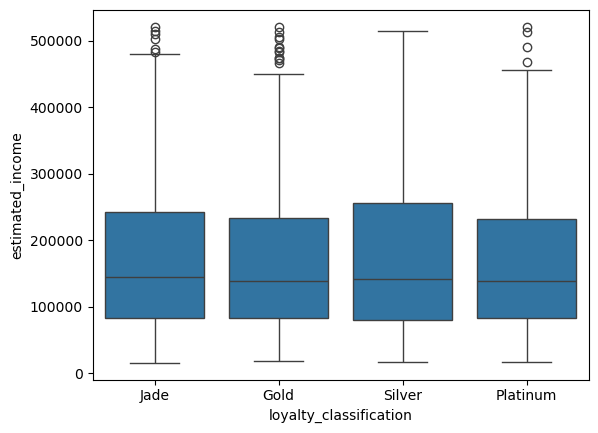

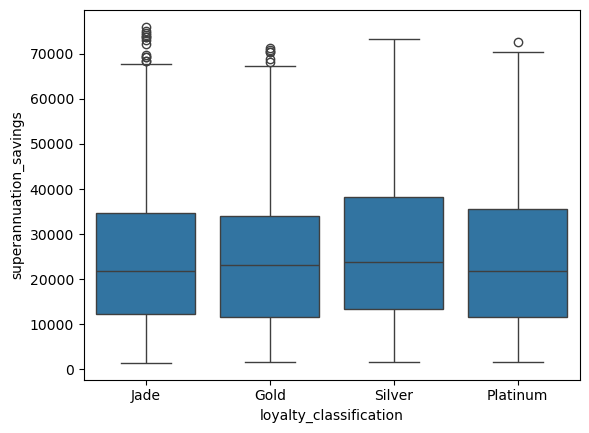

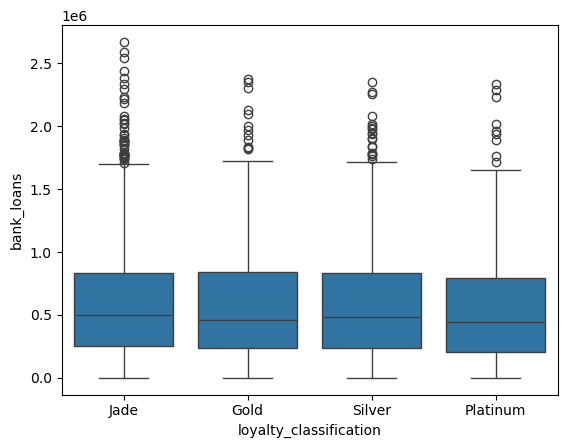

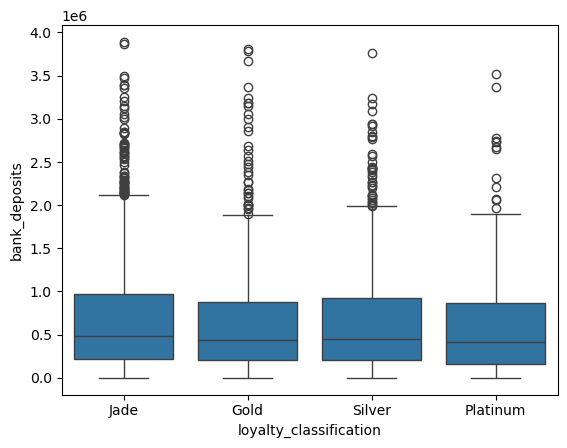

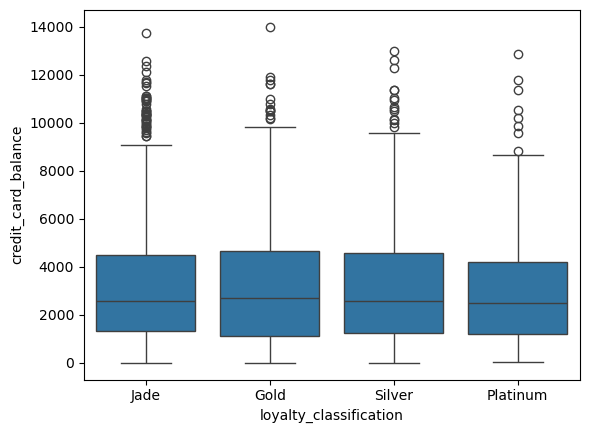

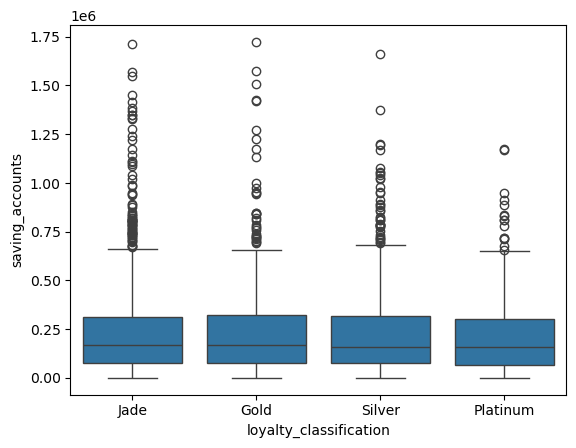

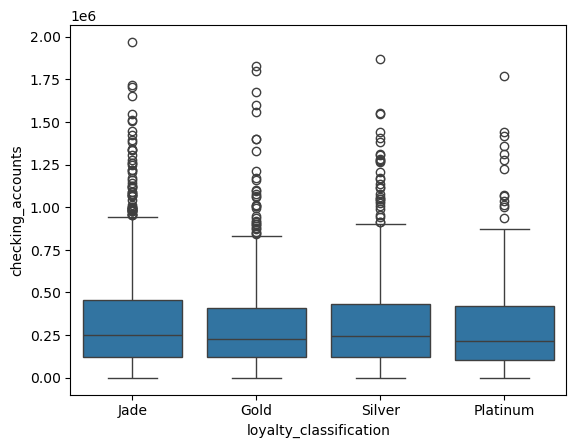

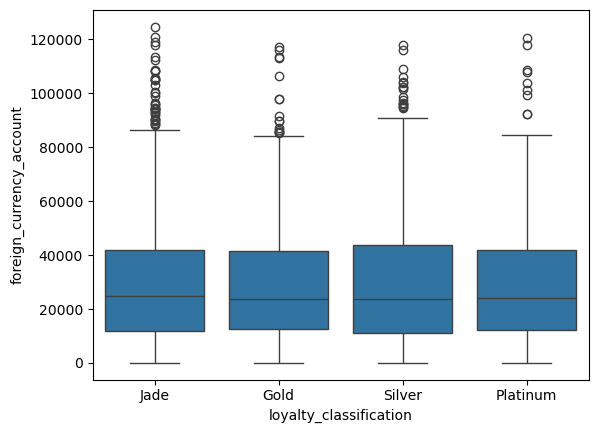

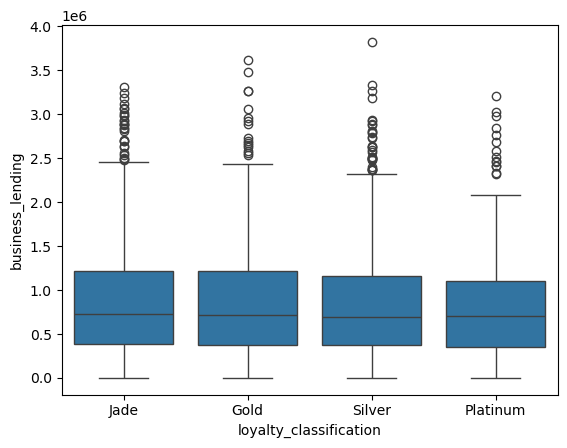

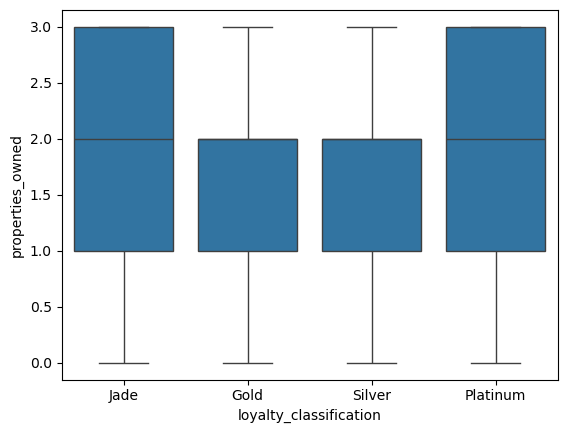

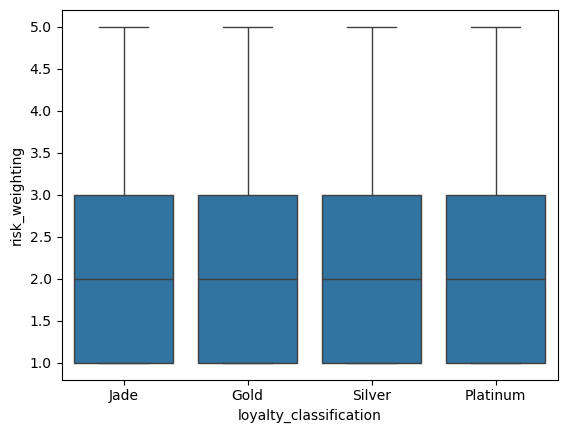

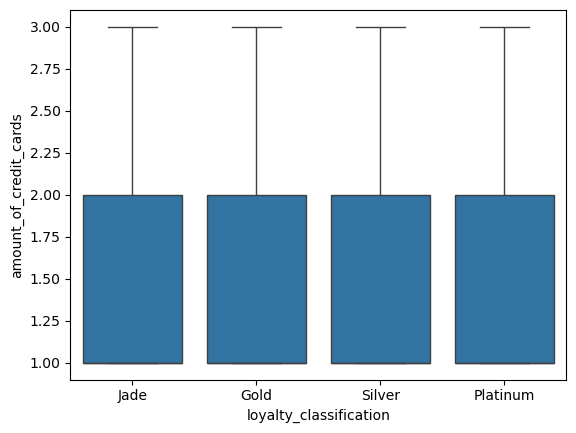

In [27]:
for i,col in enumerate(num_cols):
    plt.figure(i)
    sns.boxplot(x = df["loyalty_classification"],y = df[col])


In [28]:
# comparing risk label other numerical columns 

In [29]:
df['risk_label'].value_counts()

risk_label
Low          1200
Very Low      818
Medium        448
High          318
Very High     156
Name: count, dtype: int64

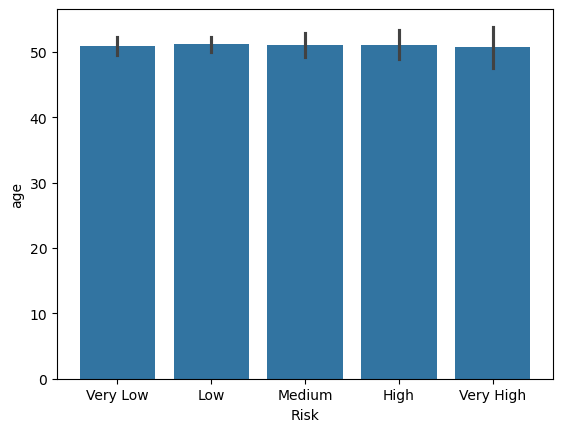

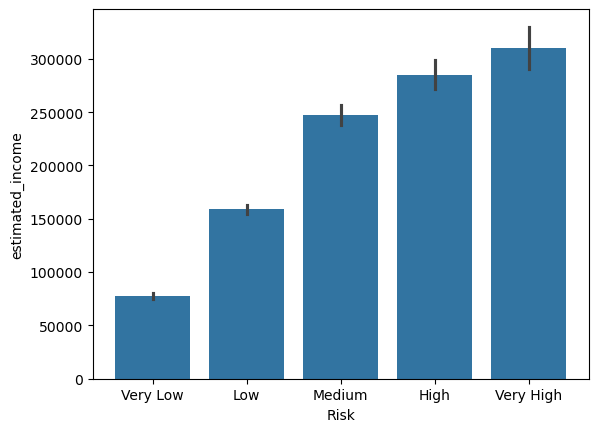

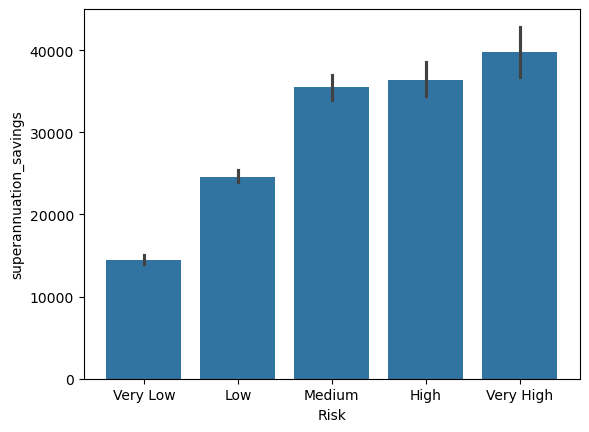

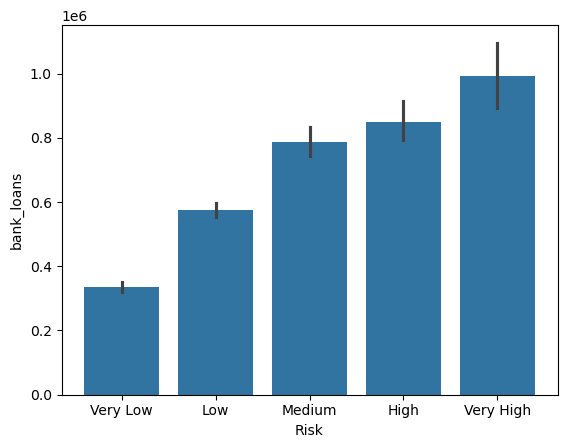

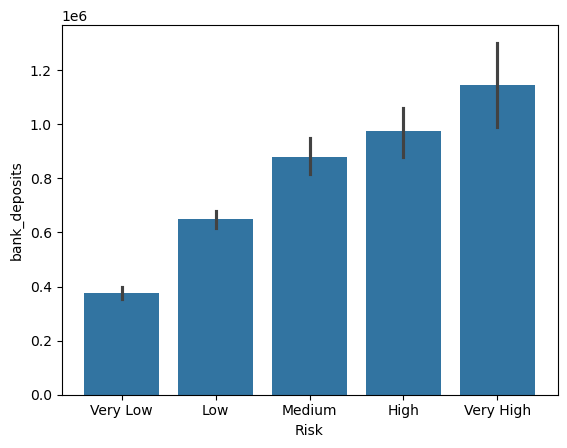

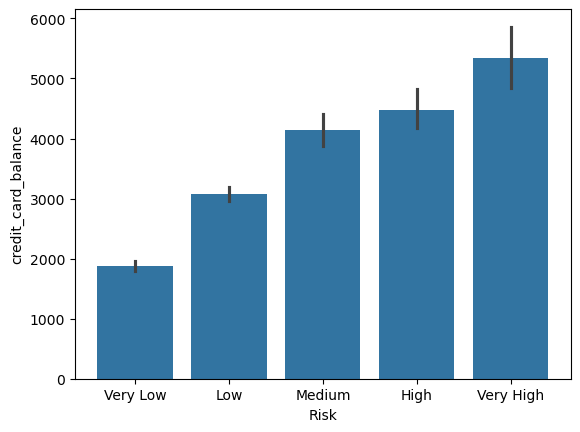

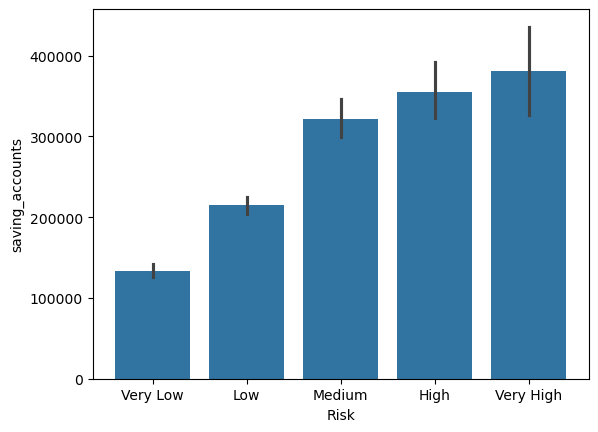

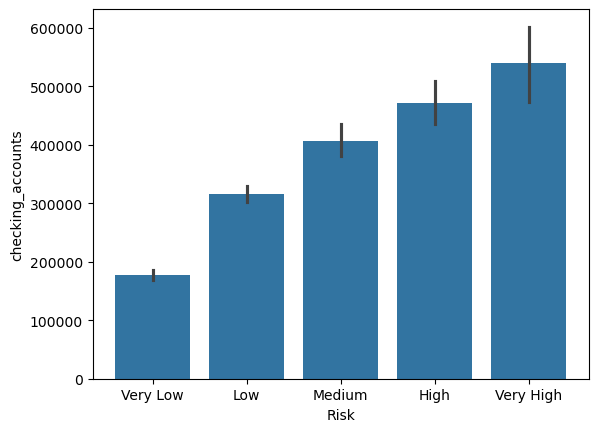

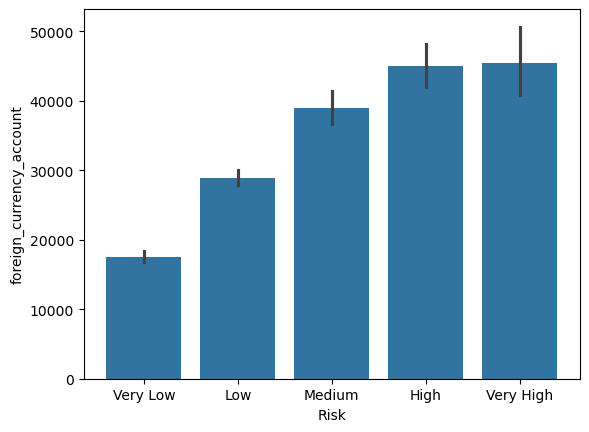

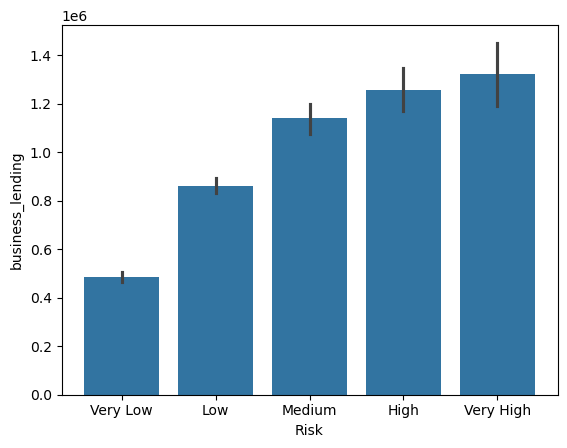

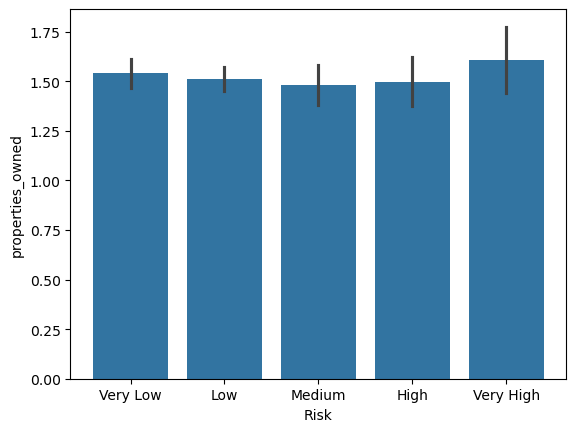

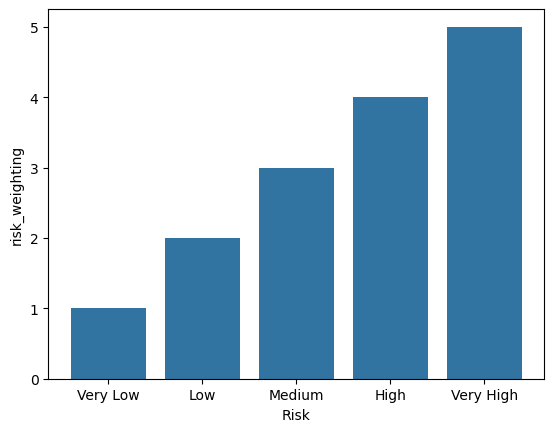

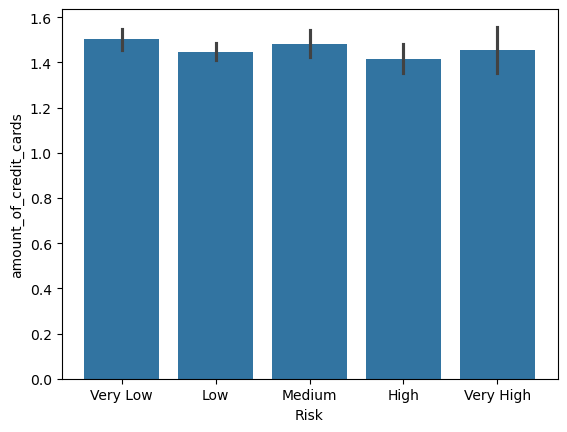

In [30]:
orders = ['Very Low','Low','Medium',"High",'Very High']
for i , col in enumerate(num_cols):
    plt.figure(i)
    sns.barplot(x = 'risk_label' ,y = col,data = df,order = orders)
    plt.xlabel('Risk')
    plt.ylabel(col)
    plt.plot()

In [31]:
# comparing banking relation categorical col with numerical col

In [32]:
df['banking_relation'].value_counts()

banking_relation
Private Bank     1318
Retail            650
Institutional     488
Commercial        484
Name: count, dtype: int64

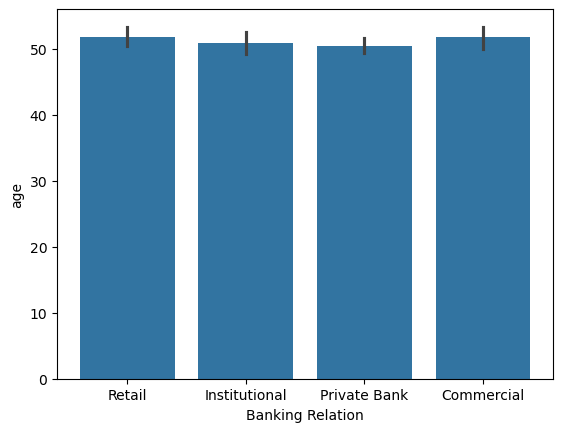

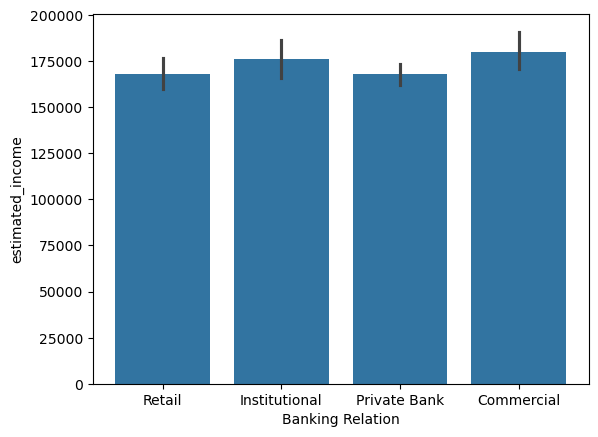

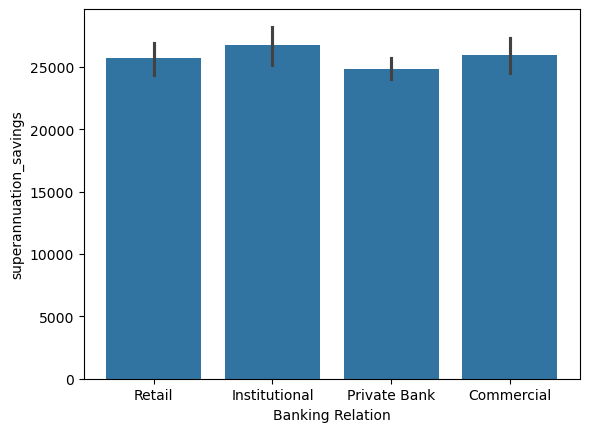

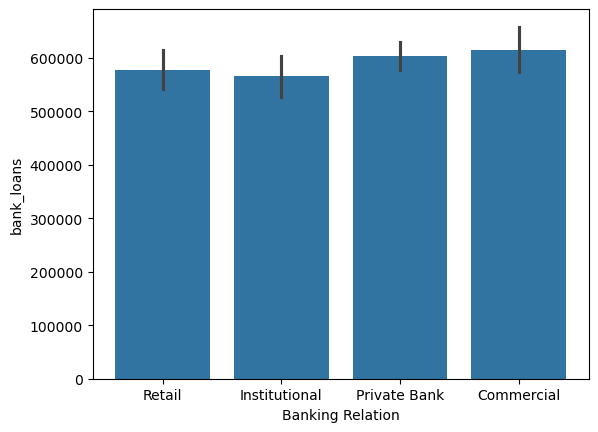

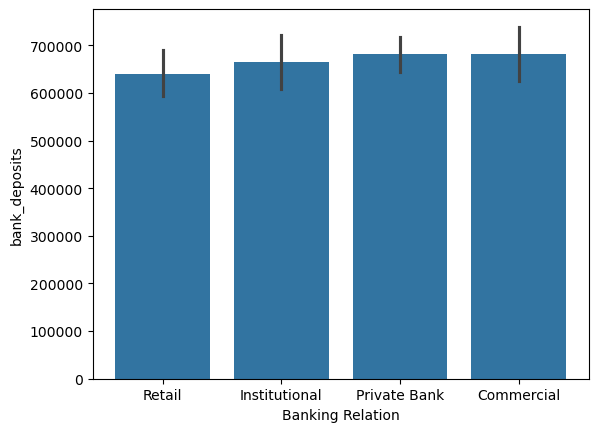

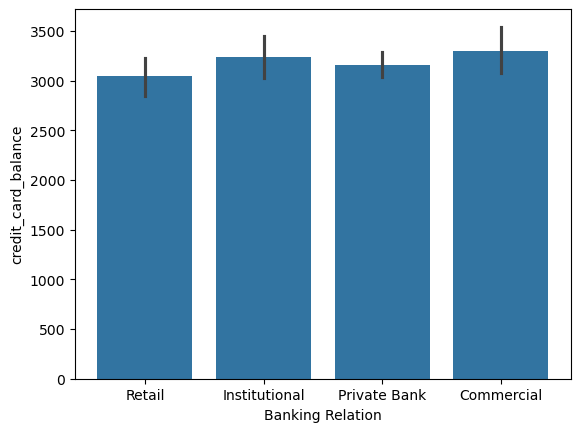

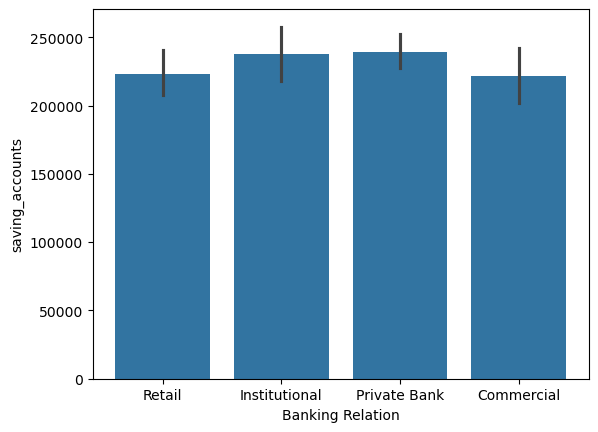

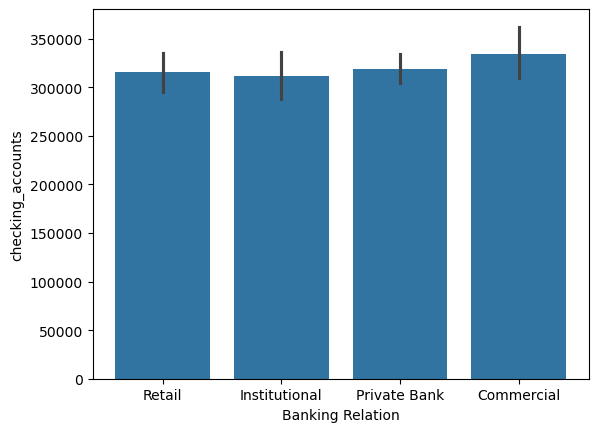

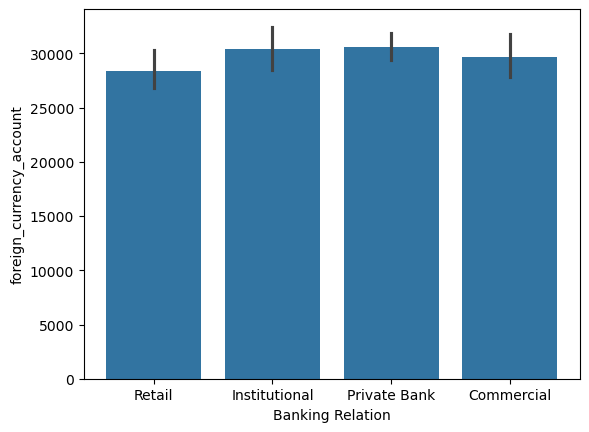

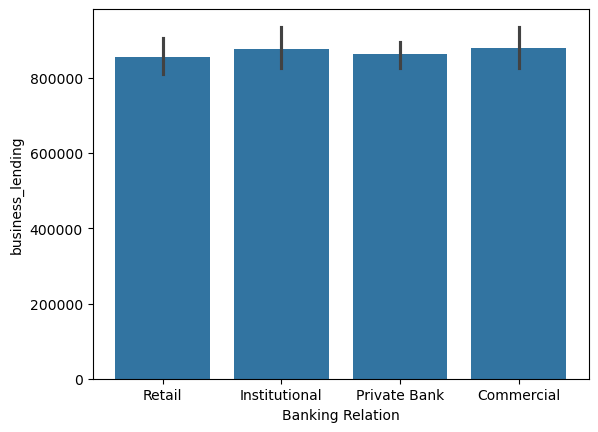

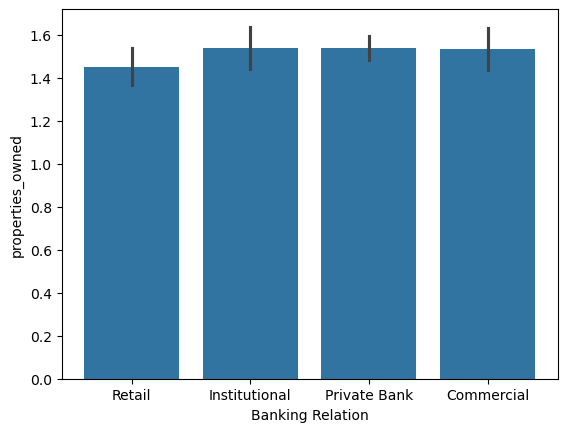

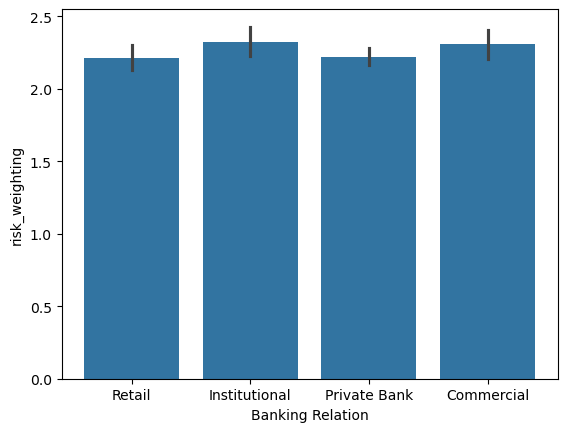

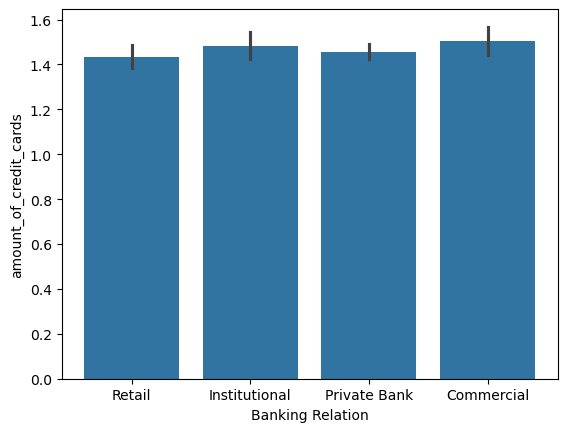

In [33]:
for i , col in enumerate(num_cols):
    plt.figure(i)
    sns.barplot(x = 'banking_relation' ,y = col,data = df)
    plt.xlabel('Banking Relation')
    plt.ylabel(col)
    plt.plot()

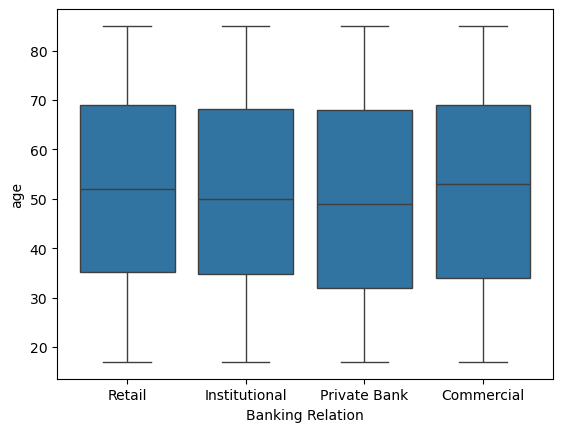

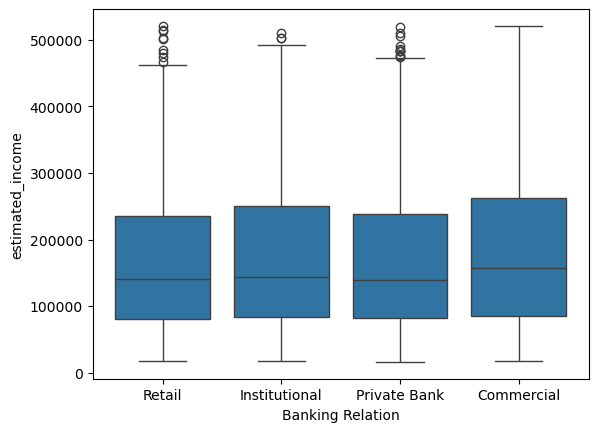

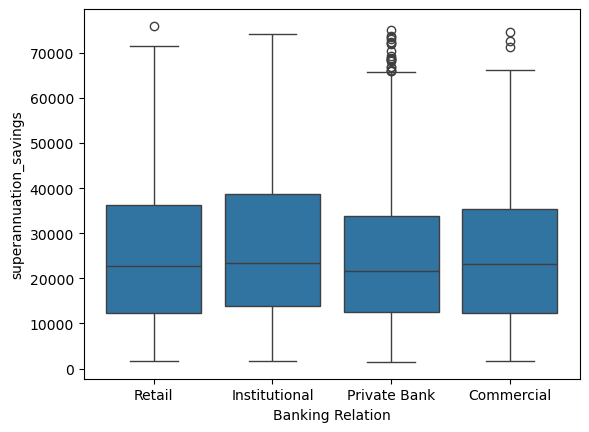

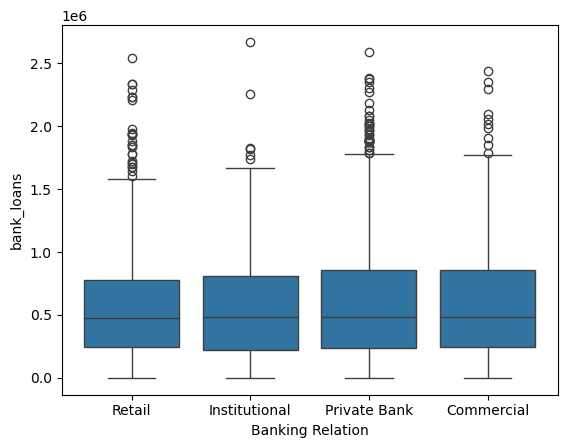

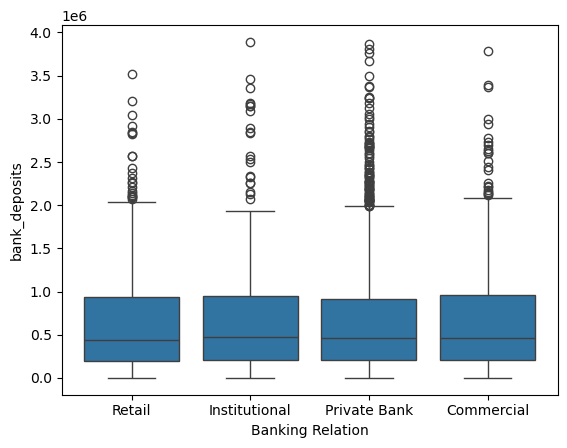

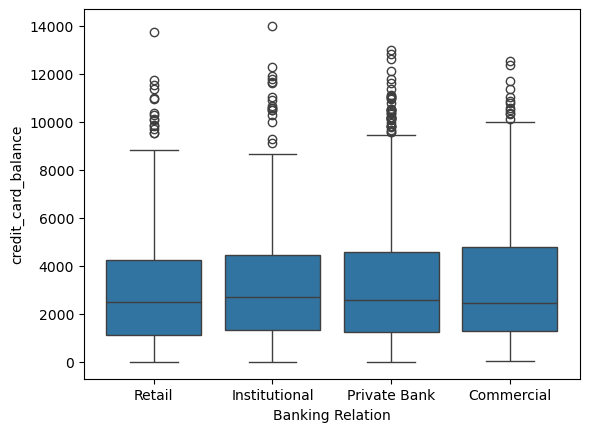

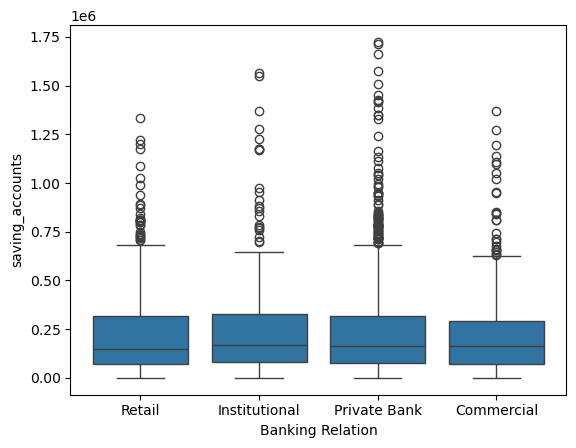

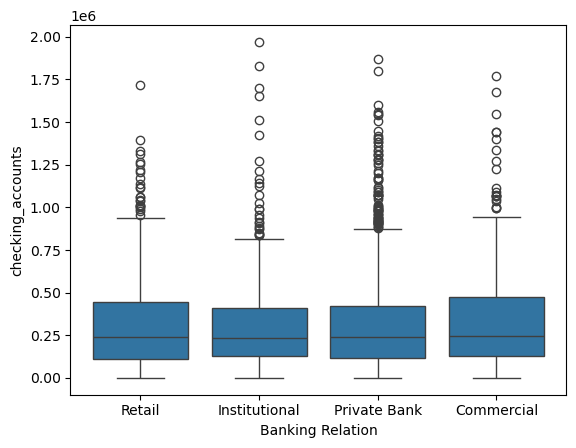

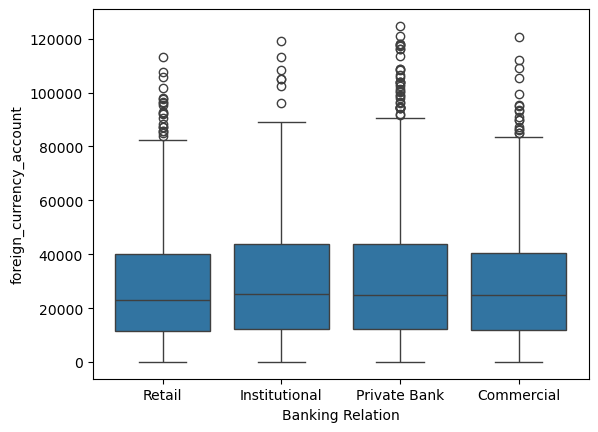

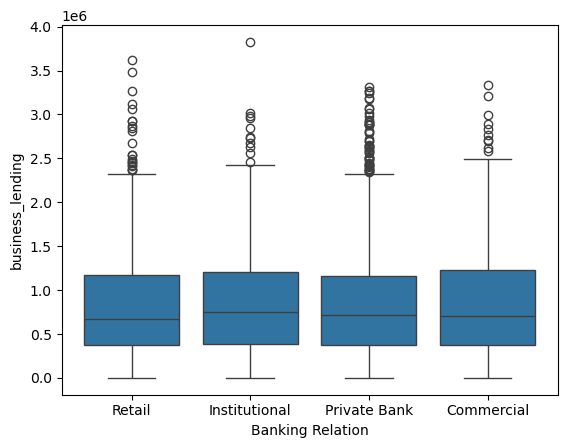

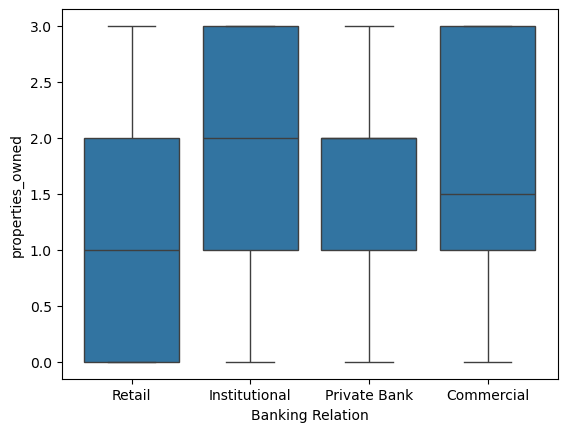

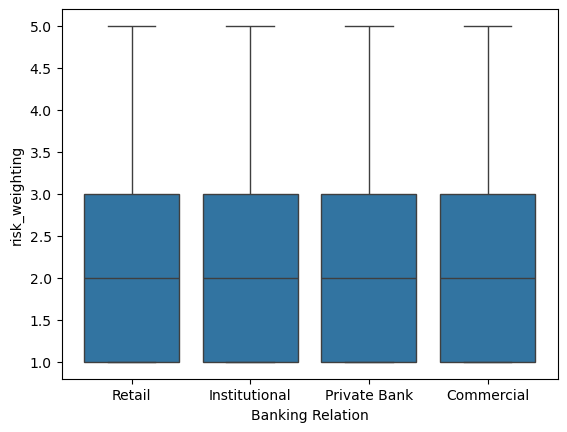

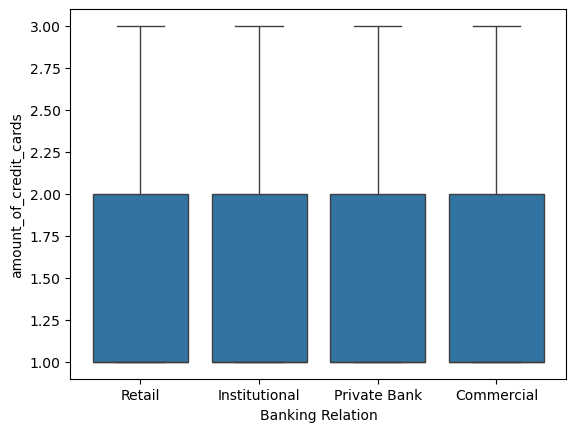

In [34]:
for i , col in enumerate(num_cols):
    plt.figure(i)
    sns.boxplot(x = 'banking_relation' ,y = col,data = df)
    plt.xlabel('Banking Relation')
    plt.ylabel(col)
    plt.plot()

# Categorical vs Categorical

In [35]:
categorical_col = ["nationality","fee_structure","loyalty_classification","amount_of_credit_cards",
                   "banking_relation","gender","risk_label","properties_label" ]

In [36]:
for i,col in enumerate(categorical_col):
    ct = pd.crosstab(df['loyalty_classification'],df[col],normalize='index')
    print(ct)
    print()

nationality              African  American     Asian  Australian  European
loyalty_classification                                                    
Gold                    0.057491  0.163763  0.257840    0.092334  0.428571
Jade                    0.060583  0.177147  0.247699    0.078221  0.436350
Platinum                0.032468  0.159091  0.259740    0.071429  0.477273
Silver                  0.068966  0.159151  0.255968    0.090186  0.425729

fee_structure               High       Low       Mid
loyalty_classification                              
Gold                    0.520906  0.184669  0.294425
Jade                    0.496933  0.182515  0.320552
Platinum                0.441558  0.188312  0.370130
Silver                  0.474801  0.202918  0.322281

loyalty_classification  Gold  Jade  Platinum  Silver
loyalty_classification                              
Gold                     1.0   0.0       0.0     0.0
Jade                     0.0   1.0       0.0     0.0
Platinum          

In [37]:
for i,col in enumerate(categorical_col):
    ct = pd.crosstab(df['loyalty_classification'],df[col])
    print(ct)
    print()

nationality             African  American  Asian  Australian  European
loyalty_classification                                                
Gold                         33        94    148          53       246
Jade                         79       231    323         102       569
Platinum                     10        49     80          22       147
Silver                       52       120    193          68       321

fee_structure           High  Low  Mid
loyalty_classification                
Gold                     299  106  169
Jade                     648  238  418
Platinum                 136   58  114
Silver                   358  153  243

loyalty_classification  Gold  Jade  Platinum  Silver
loyalty_classification                              
Gold                     574     0         0       0
Jade                       0  1304         0       0
Platinum                   0     0       308       0
Silver                     0     0         0     754

amount_of_credit_ca

# Numerical cols vs numerical cols 

In [38]:
num_cols = ['age', 'estimated_income', 'superannuation_savings', 'bank_loans',
            'bank_deposits', 'credit_card_balance', 'saving_accounts',
            'checking_accounts', 'foreign_currency_account', 'business_lending',
            'properties_owned', 'risk_weighting', 'amount_of_credit_cards']

<Axes: >

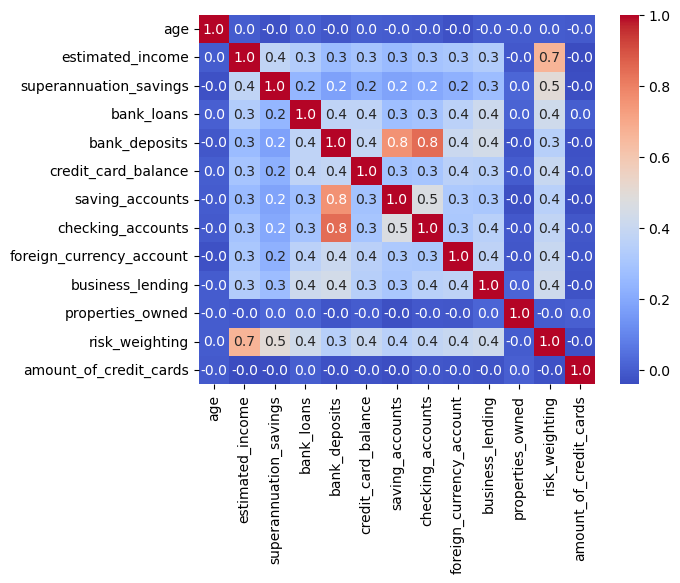

In [39]:
sns.heatmap(df[num_cols].corr(),annot=True,fmt='.1f', cmap='coolwarm')

# ML

# Feature engineering

In [40]:
df.drop(columns=['client_id', 'name', 'iaid', 'joined_bank', 
                 'banking_contact', 'location_id'], inplace=True)

In [41]:
df.drop(columns=['gender', 'banking_relation', 
                 'risk_label', 'properties_label'], inplace=True)

In [42]:
df.drop(columns=['occupation'], inplace=True)

In [43]:
df['total_assets'] = df['bank_deposits'] + df['checking_accounts'] + df['saving_accounts'] + df['foreign_currency_account'] + df['superannuation_savings']

In [44]:
df['total_liabilities'] = df['credit_card_balance'] + df['bank_loans'] + df['business_lending']

In [45]:
df['net_worth'] = df['total_assets'] - df['total_liabilities']

In [46]:
df['debt_to_income'] = df['total_liabilities'] / df['estimated_income']

In [47]:
df[['total_assets','total_liabilities','net_worth','debt_to_income']].describe()

,total_assets,total_liabilities,net_worth,debt_to_income
count,2.940000e+03,2.940000e+03,2.940000e+03,2940.000000
mean,1.277249e+06,1.462413e+06,-1.851641e+05,11.620939
std,1.081084e+06,9.308999e+05,1.036565e+06,9.654025
min,3.104090e+03,5.595170e+04,-4.251294e+06,0.390730
25%,4.812209e+05,7.726807e+05,-7.257272e+05,5.252074
50%,9.630259e+05,1.229112e+06,-1.823259e+05,8.653933
75%,1.758159e+06,1.958647e+06,3.072634e+05,14.646231
max,6.519913e+06,6.078679e+06,5.274030e+06,93.523591


In [48]:
df.columns.tolist()

['age',
 'nationality',
 'fee_structure',
 'loyalty_classification',
 'estimated_income',
 'superannuation_savings',
 'amount_of_credit_cards',
 'credit_card_balance',
 'bank_loans',
 'bank_deposits',
 'checking_accounts',
 'saving_accounts',
 'foreign_currency_account',
 'business_lending',
 'properties_owned',
 'risk_weighting',
 'brid',
 'genderid',
 'tenure_year',
 'total_assets',
 'total_liabilities',
 'net_worth',
 'debt_to_income']

In [49]:
df.groupby('loyalty_classification')['debt_to_income'].mean()

loyalty_classification
Gold        11.541036
Jade        11.857846
Platinum    11.165260
Silver      11.458188
Name: debt_to_income, dtype: float64

# ML Flow

In [50]:
df.columns

Index(['age', 'nationality', 'fee_structure', 'loyalty_classification',
       'estimated_income', 'superannuation_savings', 'amount_of_credit_cards',
       'credit_card_balance', 'bank_loans', 'bank_deposits',
       'checking_accounts', 'saving_accounts', 'foreign_currency_account',
       'business_lending', 'properties_owned', 'risk_weighting', 'brid',
       'genderid', 'tenure_year', 'total_assets', 'total_liabilities',
       'net_worth', 'debt_to_income'],
      dtype='object')

# Code of with Smote

# code with Randomsearch cv and XGBOOST

## ML Model - XGBoost Final Model
After trying multiple approaches:
- Class weights balanced → did not help minority classes
- Removed risk_weighting → no significant improvement  
- SMOTE oversampling → caused overfitting (CV 69% vs Test 34%)
- Hyperparameter tuning → model collapsed to predicting only Jade

Conclusion: Original XGBoost without modifications gives most honest 
predictions across all four loyalty tiers.

In [51]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

# Preprocessing
X = df.drop(columns=['loyalty_classification'])
y = df['loyalty_classification']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42)

num_cols_to_scale = ['age', 'estimated_income', 'superannuation_savings',
                     'amount_of_credit_cards', 'credit_card_balance', 'bank_loans',
                     'bank_deposits', 'checking_accounts', 'saving_accounts',
                     'foreign_currency_account', 'business_lending',
                     'tenure_year', 'total_assets', 'risk_weighting',
                     'total_liabilities', 'net_worth', 'debt_to_income']

cat_cols_to_encode = ['nationality', 'fee_structure', 'brid']

preprocessor = ColumnTransformer(transformers=[
    ('scale', StandardScaler(), num_cols_to_scale),
    ('encode', OneHotEncoder(drop='first', sparse_output=False), cat_cols_to_encode)
])

X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

# Final Model
xgb_final = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_final.fit(X_train_final, y_train)

y_pred = xgb_final.predict(X_test_final)

print(f"Test Accuracy: {(y_pred == y_test).mean():.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Test Accuracy: 0.3895

Classification Report:
              precision    recall  f1-score   support

        Gold       0.31      0.18      0.22       113
        Jade       0.44      0.68      0.53       260
    Platinum       0.11      0.02      0.03        60
      Silver       0.28      0.19      0.23       155

    accuracy                           0.39       588
   macro avg       0.28      0.27      0.25       588
weighted avg       0.34      0.39      0.34       588



In [52]:
import importlib
import shap
print(shap.__version__)

0.49.1


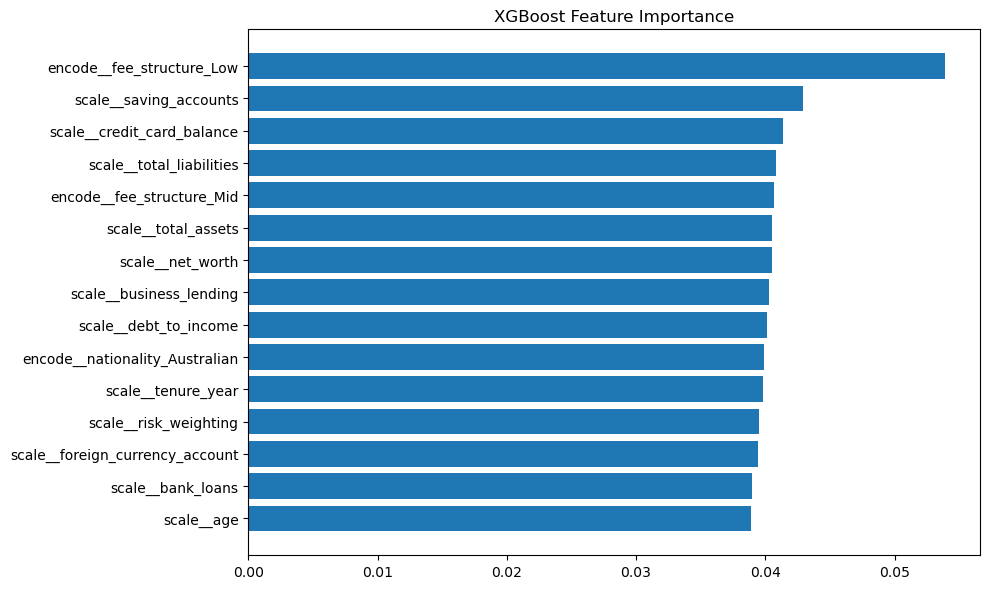

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = preprocessor.get_feature_names_out()
importances = xgb_final.feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

In [54]:
df.to_csv('banking_dashboard.csv', index=False)